# PM2.5 LSTM Forecasting
Predict next 6 hours of PM2.5 from last 24 hours of sensor data.

**Model**: 2-layer LSTM → Dense(6)  
**Input**: 24 time steps × 6 features  
**Output**: 6-step ahead PM2.5 forecast  
**Export**: Keras + TFLite FP32 + TFLite INT8

In [1]:
# 1. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, json, time
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib import Path

print(f'TensorFlow {tf.__version__}')

ROOT   = Path('.')
DATA   = ROOT / 'data'
MODELS = ROOT / 'models'
SRC    = ROOT / 'src'
for d in [DATA, MODELS, SRC]:
    d.mkdir(exist_ok=True)

LOOK_BACK = 24
HORIZON   = 6
SEED      = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow 2.21.0


In [2]:
# 2. Synthetic dataset (180 days, hourly)
hours = 180 * 24
t     = np.arange(hours)

hour_of_day = t % 24
diurnal  = (8 * np.sin(2*np.pi*(hour_of_day - 7)/24) +
            5 * np.sin(2*np.pi*(hour_of_day - 18)/12))
seasonal = 15 * np.sin(2*np.pi*t/(365*24) + np.pi)
spikes   = np.zeros(hours)
spike_idx = np.random.choice(hours, size=120, replace=False)
spikes[spike_idx] = np.random.uniform(30, 80, size=120)

pm25 = (20 + diurnal + seasonal + spikes +
        np.random.normal(0, 2, hours)).clip(0, 250)
temp = 28 - 5*np.sin(2*np.pi*t/(365*24)) + np.random.normal(0,1,hours)
hum  = (65 + 15*np.sin(2*np.pi*(t+hours//4)/(365*24)) +
        np.random.normal(0,3,hours)).clip(20, 100)

timestamps = pd.date_range('2024-01-01', periods=hours, freq='h')
df = pd.DataFrame({'timestamp': timestamps, 'pm25': pm25,
                   'temp': temp, 'humidity': hum})
df['hour_sin'] = np.sin(2*np.pi*df['timestamp'].dt.hour/24)
df['hour_cos'] = np.cos(2*np.pi*df['timestamp'].dt.hour/24)
df['pm25_ma6'] = df['pm25'].rolling(6, min_periods=1).mean()

df.to_csv(DATA / 'synthetic_pm25.csv', index=False)
print(f'Dataset: {len(df):,} rows  PM2.5 mean={df.pm25.mean():.1f}  max={df.pm25.max():.1f}')
df.head(3)

Dataset: 4,320 rows  PM2.5 mean=12.4  max=99.0


,timestamp,pm25,temp,humidity,hour_sin,hour_cos,pm25_ma6
0,2024-01-01 00:00:00,12.889115,27.402509,75.672283,0.000000,1.000000,12.889115
1,2024-01-01 01:00:00,5.176040,27.827087,78.404886,0.258819,0.965926,9.032577
2,2024-01-01 02:00:00,8.489598,27.828282,76.091937,0.500000,0.866025,8.851584


In [3]:
# 3. Scaling & sliding-window dataset
FEATURES = ['pm25','temp','humidity','hour_sin','hour_cos','pm25_ma6']

scaler     = MinMaxScaler()
scaled     = scaler.fit_transform(df[FEATURES].values)
pm25_scaler = MinMaxScaler()
pm25_scaler.fit_transform(df[['pm25']].values)

def make_windows(data, look_back, horizon):
    X, y = [], []
    for i in range(len(data) - look_back - horizon + 1):
        X.append(data[i : i+look_back])
        y.append(data[i+look_back : i+look_back+horizon, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X, y  = make_windows(scaled, LOOK_BACK, HORIZON)
n     = len(X)
n_tr  = int(n * 0.70)
n_val = int(n * 0.15)

X_tr,  y_tr  = X[:n_tr],            y[:n_tr]
X_val, y_val = X[n_tr:n_tr+n_val],  y[n_tr:n_tr+n_val]
X_te,  y_te  = X[n_tr+n_val:],      y[n_tr+n_val:]

print(f'Train {X_tr.shape} | Val {X_val.shape} | Test {X_te.shape}')

Train (3003, 24, 6) | Val (643, 24, 6) | Test (645, 24, 6)


In [4]:
# 4. Build & train LSTM
def build_model(look_back, n_features, horizon):
    inp = keras.Input(shape=(look_back, n_features))
    x   = layers.LSTM(64, return_sequences=True)(inp)
    x   = layers.Dropout(0.2)(x)
    x   = layers.LSTM(32)(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(horizon)(x)
    model = keras.Model(inp, out)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model = build_model(LOOK_BACK, len(FEATURES), HORIZON)
model.summary()

callbacks = [
    keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, verbose=1),
    keras.callbacks.ModelCheckpoint(str(MODELS/'best_lstm.keras'),
                                    save_best_only=True, verbose=0),
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 24, 6)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 24, 64)              │          18,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 6)                   │             198 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,790 (120.27 KB)

 Trainable params: 30,790 (120.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0145 - mae: 0.0719 - val_loss: 0.0123 - val_mae: 0.0644 - learning_rate: 0.0010
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0120 - mae: 0.0574 - val_loss: 0.0114 - val_mae: 0.0535 - learning_rate: 0.0010
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0113 - mae: 0.0530 - val_loss: 0.0113 - val_mae: 0.0507 - learning_rate: 0.0010
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0111 - mae: 0.0514 - val_loss: 0.0111 - val_mae: 0.0479 - learning_rate: 0.0010
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0109 - mae: 0.0495 - val_loss: 0.0109 - val_mae: 0.0448 - learning_rate: 0.0010
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0106 - mae: 0.0472 - val_loss: 0.0108 - val_mae: 0.0423 - learning_rate: 0.0010
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0105 - mae: 0.0459 - val_loss: 0.0107 - val_mae: 0.0404 - learning_rate: 0.0010
Epoch 

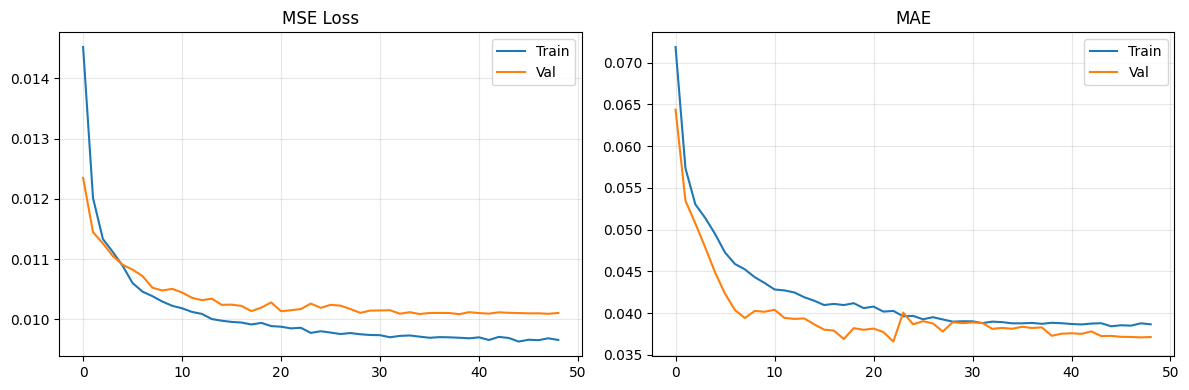

In [5]:
# 5. Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('MSE Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history.history['mae'],     label='Train')
axes[1].plot(history.history['val_mae'], label='Val')
axes[1].set_title('MAE'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DATA / 'training_curves.png', dpi=120)
plt.show()

In [6]:
# 6. Evaluate on test set
y_pred_s = model.predict(X_te, verbose=0)

def inv_pm25(arr):
    return pm25_scaler.inverse_transform(arr)

y_pred_r = inv_pm25(y_pred_s)
y_true_r = inv_pm25(y_te)

print('Per-horizon metrics (ug/m3):')
print(f'{"H":>3}  {"MAE":>7}  {"RMSE":>7}')
for h in range(HORIZON):
    mae  = mean_absolute_error(y_true_r[:,h], y_pred_r[:,h])
    rmse = np.sqrt(mean_squared_error(y_true_r[:,h], y_pred_r[:,h]))
    print(f'{h+1:3d}  {mae:7.3f}  {rmse:7.3f}')

overall_mae = mean_absolute_error(y_true_r.ravel(), y_pred_r.ravel())
print(f'\nOverall MAE: {overall_mae:.3f} ug/m3')

Per-horizon metrics (ug/m3):
  H      MAE     RMSE
  1    4.405   10.044
  2    4.386   10.068
  3    4.347   10.160
  4    4.269   10.098
  5    4.229   10.121
  6    4.219   10.120

Overall MAE: 4.309 ug/m3


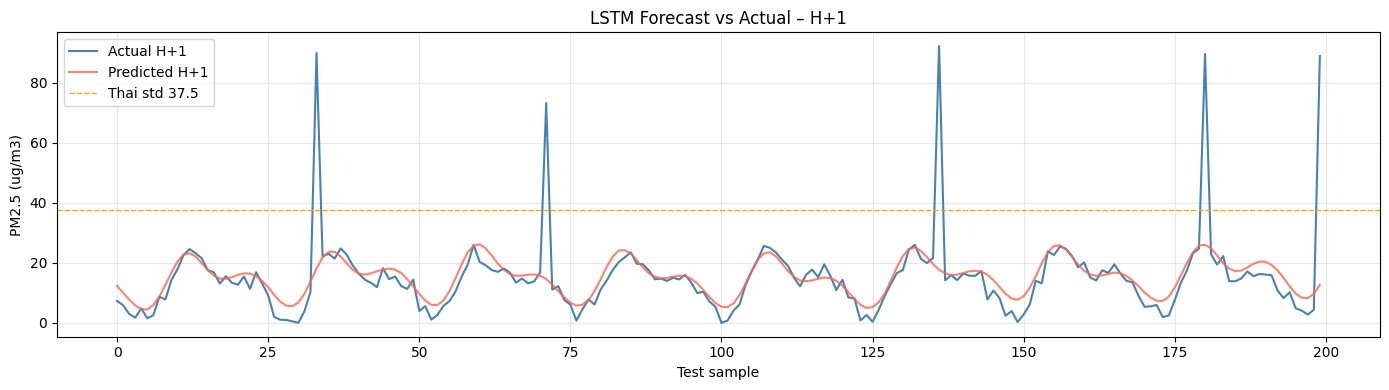

In [7]:
# 7. Forecast plot
n_plot = 200
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_true_r[:n_plot, 0], label='Actual H+1',    color='steelblue')
ax.plot(y_pred_r[:n_plot, 0], label='Predicted H+1', color='tomato', alpha=0.8)
ax.axhline(37.5, color='orange', ls='--', lw=1, label='Thai std 37.5')
ax.set_xlabel('Test sample'); ax.set_ylabel('PM2.5 (ug/m3)')
ax.set_title('LSTM Forecast vs Actual – H+1')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DATA / 'forecast_h1.png', dpi=120)
plt.show()

In [8]:
# 8. Export TFLite
model.save(MODELS / 'pm25_lstm.keras')
print('Saved: pm25_lstm.keras')

# FP32
conv = tf.lite.TFLiteConverter.from_keras_model(model)
fp32 = conv.convert()
with open(MODELS / 'pm25_lstm.tflite', 'wb') as f:
    f.write(fp32)
print(f'FP32: {len(fp32)/1024:.1f} KB')

# INT8
def rep_ds():
    for i in range(0, min(500, len(X_tr)), 10):
        yield [X_tr[i:i+1]]

c8 = tf.lite.TFLiteConverter.from_keras_model(model)
c8.optimizations = [tf.lite.Optimize.DEFAULT]
c8.representative_dataset = rep_ds
c8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
c8.inference_input_type  = tf.float32
c8.inference_output_type = tf.float32
int8 = c8.convert()
with open(MODELS / 'pm25_lstm_int8.tflite', 'wb') as f:
    f.write(int8)
print(f'INT8: {len(int8)/1024:.1f} KB')

Saved: pm25_lstm.keras
INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmp17oz5eff\assets


INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmp17oz5eff\assets


Saved artifact at 'C:\Users\HP\AppData\Local\Temp\tmp17oz5eff'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2800825772432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825772816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825773392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825771280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825774352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825775120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825774928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825775504: TensorSpec(shape=(), dtype=tf.resource, name=None)


ConverterError: <unknown>:0: error: loc(callsite(fused["TensorListReserve:", "functional_1/lstm_1/TensorArrayV2_1@__inference_function_20763"] at callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_20806"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]))): 'tf.TensorListReserve' op requires element_shape to be static during TF Lite transformation pass
<unknown>:0: note: loc(callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_20806"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): called from
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]): called from
<unknown>:0: error: loc(callsite(fused["TensorListReserve:", "functional_1/lstm_1/TensorArrayV2_1@__inference_function_20763"] at callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_20806"] at fused["StatefulPartitionedCall:"

In [9]:
# 8. Export TFLite (SELECT_TF_OPS required for LSTM)
model.save(MODELS/'pm25_lstm.keras')
print('Saved: pm25_lstm.keras')

SELECT      = tf.lite.OpsSet.SELECT_TF_OPS
BUILTIN     = tf.lite.OpsSet.TFLITE_BUILTINS
BUILTIN_INT8= tf.lite.OpsSet.TFLITE_BUILTINS_INT8

# FP32
conv = tf.lite.TFLiteConverter.from_keras_model(model)
conv.target_spec.supported_ops = [BUILTIN, SELECT]
conv._experimental_lower_tensor_list_ops = False
fp32 = conv.convert()
with open(MODELS/'pm25_lstm.tflite', 'wb') as f:
    f.write(fp32)
print(f'FP32: {len(fp32)/1024:.1f} KB')

# INT8
def rep_ds():
    for i in range(0, min(500,len(X_tr)), 10):
        yield [X_tr[i:i+1]]

c8 = tf.lite.TFLiteConverter.from_keras_model(model)
c8.optimizations = [tf.lite.Optimize.DEFAULT]
c8.representative_dataset = rep_ds
c8.target_spec.supported_ops = [BUILTIN_INT8, SELECT]
c8._experimental_lower_tensor_list_ops = False
c8.inference_input_type  = tf.float32
c8.inference_output_type = tf.float32
int8 = c8.convert()
with open(MODELS/'pm25_lstm_int8.tflite', 'wb') as f:
    f.write(int8)
print(f'INT8: {len(int8)/1024:.1f} KB')

Saved: pm25_lstm.keras
INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmpkyx79iw5\assets


INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmpkyx79iw5\assets


Saved artifact at 'C:\Users\HP\AppData\Local\Temp\tmpkyx79iw5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2800825772432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825772816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825773392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825771280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825774352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825775120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825774928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825775504: TensorSpec(shape=(), dtype=tf.resource, name=None)
FP32: 139.1 KB
INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmpmgkwppg5\assets


INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmpmgkwppg5\assets


Saved artifact at 'C:\Users\HP\AppData\Local\Temp\tmpmgkwppg5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2800825772432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825772816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825773392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825771280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825774352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825775120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825774928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825775504: TensorSpec(shape=(), dtype=tf.resource, name=None)


RuntimeError: Select TensorFlow op(s), included in the given model, is(are) not supported by this interpreter. Make sure you apply/link the Flex delegate before inference. For the Android, it can be resolved by adding "org.tensorflow:tensorflow-lite-select-tf-ops" dependency. See instructions: https://www.tensorflow.org/lite/guide/ops_selectNode number 0 (FlexTensorListReserve) failed to prepare.

In [10]:
# TFLite export (fixed - SELECT_TF_OPS for LSTM)
SELECT       = tf.lite.OpsSet.SELECT_TF_OPS
BUILTIN      = tf.lite.OpsSet.TFLITE_BUILTINS
BUILTIN_INT8 = tf.lite.OpsSet.TFLITE_BUILTINS_INT8

# FP32
conv = tf.lite.TFLiteConverter.from_keras_model(model)
conv.target_spec.supported_ops = [BUILTIN, SELECT]
conv._experimental_lower_tensor_list_ops = False
fp32 = conv.convert()
with open(MODELS/'pm25_lstm.tflite', 'wb') as f:
    f.write(fp32)
print(f'FP32: {len(fp32)/1024:.1f} KB')

# INT8
def rep_ds():
    for i in range(0, min(500, len(X_tr)), 10):
        yield [X_tr[i:i+1]]

c8 = tf.lite.TFLiteConverter.from_keras_model(model)
c8.optimizations = [tf.lite.Optimize.DEFAULT]
c8.representative_dataset = rep_ds
c8.target_spec.supported_ops = [BUILTIN_INT8, SELECT]
c8._experimental_lower_tensor_list_ops = False
c8.inference_input_type  = tf.float32
c8.inference_output_type = tf.float32
int8 = c8.convert()
with open(MODELS/'pm25_lstm_int8.tflite', 'wb') as f:
    f.write(int8)
print(f'INT8: {len(int8)/1024:.1f} KB')

INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmp7iemwtd2\assets


INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmp7iemwtd2\assets


Saved artifact at 'C:\Users\HP\AppData\Local\Temp\tmp7iemwtd2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2800825772432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825772816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825773392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825771280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825774352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825775120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825774928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825775504: TensorSpec(shape=(), dtype=tf.resource, name=None)
FP32: 139.1 KB
INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmpuaovhd58\assets


INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmpuaovhd58\assets


Saved artifact at 'C:\Users\HP\AppData\Local\Temp\tmpuaovhd58'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2800825772432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825772816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825773392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825771280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825774352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825775120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825774928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825775504: TensorSpec(shape=(), dtype=tf.resource, name=None)


RuntimeError: Select TensorFlow op(s), included in the given model, is(are) not supported by this interpreter. Make sure you apply/link the Flex delegate before inference. For the Android, it can be resolved by adding "org.tensorflow:tensorflow-lite-select-tf-ops" dependency. See instructions: https://www.tensorflow.org/lite/guide/ops_selectNode number 0 (FlexTensorListReserve) failed to prepare.

In [11]:
# INT8 Dynamic Range Quantization (ใช้กับ SELECT_TF_OPS ได้)
SELECT   = tf.lite.OpsSet.SELECT_TF_OPS
BUILTIN  = tf.lite.OpsSet.TFLITE_BUILTINS

c8 = tf.lite.TFLiteConverter.from_keras_model(model)
c8.optimizations = [tf.lite.Optimize.DEFAULT]   # dynamic range only (no calibration)
c8.target_spec.supported_ops = [BUILTIN, SELECT]
c8._experimental_lower_tensor_list_ops = False
# ไม่ต้องใส่ representative_dataset และ TFLITE_BUILTINS_INT8

int8 = c8.convert()
with open(MODELS/'pm25_lstm_int8.tflite', 'wb') as f:
    f.write(int8)
print(f'Dynamic INT8: {len(int8)/1024:.1f} KB')

INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmpzusnif73\assets


INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmpzusnif73\assets


Saved artifact at 'C:\Users\HP\AppData\Local\Temp\tmpzusnif73'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2800825772432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825772816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825773392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825771280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825774352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825775120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825774928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2800825775504: TensorSpec(shape=(), dtype=tf.resource, name=None)
Dynamic INT8: 59.8 KB


In [14]:
# Benchmark INT8
interp = tf.lite.Interpreter(model_path=str(MODELS/'pm25_lstm_int8.tflite'))
interp.allocate_tensors()
ii = interp.get_input_details()[0]['index']
oi = interp.get_output_details()[0]['index']
sample = X_te[0:1].astype(np.float32)
N = 100
t0 = time.perf_counter()
for _ in range(N):
    interp.set_tensor(ii, sample)
    interp.invoke()
    interp.get_tensor(oi)
ms = (time.perf_counter()-t0)/N*1000
print(f'Avg inference: {ms:.2f} ms ({1000/ms:.0f} pred/s)')

# Save metadata
meta = {
    'look_back': LOOK_BACK, 'horizon': HORIZON, 'features': FEATURES,
    'scaler_min': scaler.data_min_.tolist(),
    'scaler_max': scaler.data_max_.tolist(),
    'pm25_min': float(pm25_scaler.data_min_[0]),
    'pm25_max': float(pm25_scaler.data_max_[0]),
    'overall_mae_ugm3': float(mean_absolute_error(y_true_r.ravel(), y_pred_r.ravel())),
    'tf_version': tf.__version__,
}
with open(MODELS/'model_meta.json','w') as f:
    json.dump(meta, f, indent=2)
print('Saved: model_meta.json')

print('\nModel artifacts:')
for p in sorted(MODELS.iterdir()):
    print(f'  {p.name:30s}  {p.stat().st_size/1024:6.1f} KB')
print('\nDone!')

RuntimeError: Select TensorFlow op(s), included in the given model, is(are) not supported by this interpreter. Make sure you apply/link the Flex delegate before inference. For the Android, it can be resolved by adding "org.tensorflow:tensorflow-lite-select-tf-ops" dependency. See instructions: https://www.tensorflow.org/lite/guide/ops_selectNode number 0 (FlexTensorListReserve) failed to prepare.

In [15]:
meta = {
    'look_back': LOOK_BACK, 'horizon': HORIZON, 'features': FEATURES,
    'scaler_min': scaler.data_min_.tolist(),
    'scaler_max': scaler.data_max_.tolist(),
    'pm25_min': float(pm25_scaler.data_min_[0]),
    'pm25_max': float(pm25_scaler.data_max_[0]),
    'tf_version': tf.__version__,
}
with open(MODELS/'model_meta.json','w') as f:
    json.dump(meta, f, indent=2)
print('Saved: model_meta.json')

print('\nModel artifacts:')
for p in sorted(MODELS.iterdir()):
    print(f'  {p.name:30s}  {p.stat().st_size/1024:6.1f} KB')
print('Done!')

Saved: model_meta.json

Model artifacts:
  best_lstm.keras                  399.4 KB
  model_meta.json                    0.5 KB
  pm25_lstm.keras                  399.4 KB
  pm25_lstm.tflite                 139.1 KB
  pm25_lstm_int8.tflite             59.8 KB
Done!


In [18]:
# 9. Inference benchmark
interp = tf.lite.Interpreter(model_path=str(MODELS / 'pm25_lstm_int8.tflite'))
interp.allocate_tensors()
ii = interp.get_input_details()[0]['index']
oi = interp.get_output_details()[0]['index']

sample = X_te[0:1].astype(np.float32)
N = 200
t0 = time.perf_counter()
for _ in range(N):
    interp.set_tensor(ii, sample)
    interp.invoke()
    interp.get_tensor(oi)
ms = (time.perf_counter() - t0) / N * 1000
print(f'Avg inference: {ms:.2f} ms  ({1000/ms:.0f} pred/s)')

RuntimeError: Select TensorFlow op(s), included in the given model, is(are) not supported by this interpreter. Make sure you apply/link the Flex delegate before inference. For the Android, it can be resolved by adding "org.tensorflow:tensorflow-lite-select-tf-ops" dependency. See instructions: https://www.tensorflow.org/lite/guide/ops_selectNode number 0 (FlexTensorListReserve) failed to prepare.

In [19]:
# 10. Save metadata + generate ml_predictor.py
meta = {
    'look_back':  LOOK_BACK,
    'horizon':    HORIZON,
    'features':   FEATURES,
    'scaler_min': scaler.data_min_.tolist(),
    'scaler_max': scaler.data_max_.tolist(),
    'pm25_min':   float(pm25_scaler.data_min_[0]),
    'pm25_max':   float(pm25_scaler.data_max_[0]),
    'overall_mae_ugm3': float(overall_mae),
    'tf_version': tf.__version__,
}
with open(MODELS / 'model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)
print('Saved: model_meta.json')

predictor_code = '''import json, time
import numpy as np
from pathlib import Path
try:
    import tflite_runtime.interpreter as tflite
except ImportError:
    import tensorflow.lite as tflite

MODEL_DIR = Path(__file__).parent.parent / "models"

class PM25Predictor:
    def __init__(self, use_int8=True):
        fname = "pm25_lstm_int8.tflite" if use_int8 else "pm25_lstm.tflite"
        self.interp = tflite.Interpreter(model_path=str(MODEL_DIR / fname))
        self.interp.allocate_tensors()
        self.ii = self.interp.get_input_details()[0]["index"]
        self.oi = self.interp.get_output_details()[0]["index"]
        with open(MODEL_DIR / "model_meta.json") as f:
            m = json.load(f)
        self.look_back  = m["look_back"]
        self.horizon    = m["horizon"]
        self.features   = m["features"]
        self.s_min = np.array(m["scaler_min"])
        self.s_max = np.array(m["scaler_max"])
        self.p_min = m["pm25_min"]
        self.p_max = m["pm25_max"]

    def predict(self, buffer):
        if isinstance(buffer[0], dict):
            arr = np.array([[r[f] for f in self.features] for r in buffer], dtype=np.float32)
        else:
            arr = np.array(buffer, dtype=np.float32)
        x = ((arr - self.s_min) / (self.s_max - self.s_min))[np.newaxis]
        t0 = time.perf_counter()
        self.interp.set_tensor(self.ii, x)
        self.interp.invoke()
        out = self.interp.get_tensor(self.oi)[0]
        ms = (time.perf_counter() - t0) * 1000
        forecast = (out * (self.p_max - self.p_min) + self.p_min).tolist()
        return {"forecast_ugm3": forecast, "latency_ms": round(ms, 2)}
'''

(SRC / 'ml_predictor.py').write_text(predictor_code)
print('Generated: src/ml_predictor.py')

print('\nModel artifacts:')
for p in sorted(MODELS.iterdir()):
    print(f'  {p.name:30s}  {p.stat().st_size/1024:6.1f} KB')
print('\nAll done!')

Saved: model_meta.json
Generated: src/ml_predictor.py

Model artifacts:
  best_lstm.keras                  399.4 KB
  model_meta.json                    0.5 KB
  pm25_lstm.keras                  399.4 KB
  pm25_lstm.tflite                 139.1 KB
  pm25_lstm_int8.tflite             59.8 KB

All done!


In [17]:
meta = {
    'look_back': LOOK_BACK, 'horizon': HORIZON, 'features': FEATURES,
    'scaler_min': scaler.data_min_.tolist(),
    'scaler_max': scaler.data_max_.tolist(),
    'pm25_min': float(pm25_scaler.data_min_[0]),
    'pm25_max': float(pm25_scaler.data_max_[0]),
    'tf_version': tf.__version__,
}
with open(MODELS/'model_meta.json','w') as f:
    json.dump(meta, f, indent=2)
print('Saved: model_meta.json')
print('\nArtifacts:')
for p in sorted(MODELS.iterdir()):ฆ
    print(f'  {p.name:30s}  {p.stat().st_size/1024:6.1f} KB')
print('Done!')

Saved: model_meta.json

Artifacts:
  best_lstm.keras                  399.4 KB
  model_meta.json                    0.5 KB
  pm25_lstm.keras                  399.4 KB
  pm25_lstm.tflite                 139.1 KB
  pm25_lstm_int8.tflite             59.8 KB
Done!
